#📌 Extracción

In [2]:
import pandas as pd

In [3]:
url = "https://raw.githubusercontent.com/Mijael126/Challenge-telecomX-/refs/heads/main/TelecomX_Data.json"
datos =  pd.read_json(url)
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [13]:
import pandas as pd

# Supongamos que quieres expandir la columna 'customer'
df_customer = pd.json_normalize(datos['customer'])

# Si quieres expandir varias columnas, puedes concatenarlas
df_phone = pd.json_normalize(datos['phone'])
df_internet = pd.json_normalize(datos['internet'])
df_account = pd.json_normalize(datos['account'])

# Luego unes todo con las columnas originales que quieres mantener
df_normalizado = pd.concat(
    [datos[['customerID','Churn']], df_customer, df_phone, df_internet, df_account],
    axis=1
)

df_normalizado.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [14]:
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [16]:
# Duplicados
print("Duplicados:", df_normalizado.duplicated().sum())

# Valores únicos en categóricas
for col in df_normalizado.select_dtypes(include='object').columns:
    print(col, df_normalizado[col].unique())

# Conversión de Charges.Total
df_normalizado['Charges.Total'] = pd.to_numeric(df_normalizado['Charges.Total'], errors='coerce')

# Verificar nulos después de conversión
print(df_normalizado.isnull().sum())


Duplicados: 0
customerID ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn ['No' 'Yes' '']
gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['Yes' 'No']
PhoneService ['Yes' 'No']
MultipleLines ['No' 'Yes' 'No phone service']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['Yes' 'No' 'No internet service']
StreamingTV ['Yes' 'No' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['One year' 'Month-to-month' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
Charges.Total ['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']
customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents      

In [19]:
import numpy as np


# 1. Corregir valores vacíos en Churn
df_normalizado['Churn'] = df_normalizado['Churn'].replace('', np.nan)

# 2. Revisar cuántos nulos quedan en Churn
print(df_normalizado['Churn'].isnull().sum())

# 3. Decidir tratamiento: eliminar o imputar
df_normalizado = df_normalizado.dropna(subset=['Churn'])

# 4. Revisar los 11 nulos en Charges.Total
print(df_normalizado['Charges.Total'].isnull().sum())

# 5. Opciones: eliminar filas con Charges.Total nulo
df_normalizado = df_normalizado.dropna(subset=['Charges.Total'])

# Imputar Charges.Total si es posible
df_normalizado['Charges.Total'] = df_normalizado['Charges.Total'].fillna(
    df_normalizado['Charges.Monthly'] * df_normalizado['tenure']
)



0
0


#📊 Carga y análisis

In [20]:
df_normalizado.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
df_normalizado.drop(columns=['SeniorCitizen']).describe()

,tenure,Charges.Monthly,Charges.Total
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


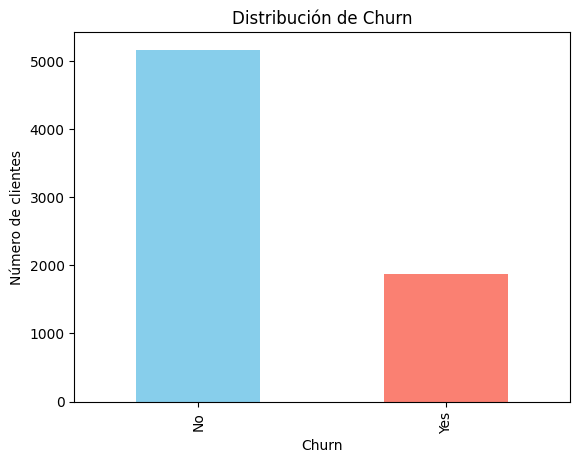

In [22]:
import matplotlib.pyplot as plt

# Conteo de churn
churn_counts = df_normalizado['Churn'].value_counts()

# Gráfico de barras
churn_counts.plot(kind='bar', color=['skyblue','salmon'])
plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")
plt.show()


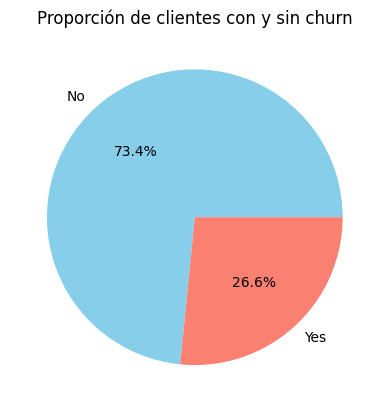

In [23]:
# Gráfico de torta (proporción)
churn_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue','salmon'])
plt.title("Proporción de clientes con y sin churn")
plt.ylabel("")  # ocultar etiqueta extra
plt.show()


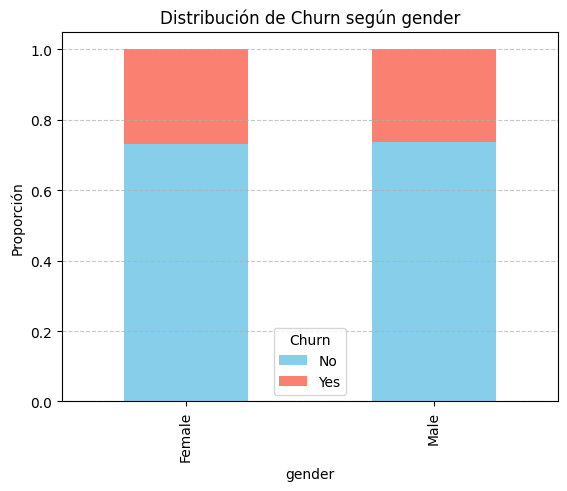

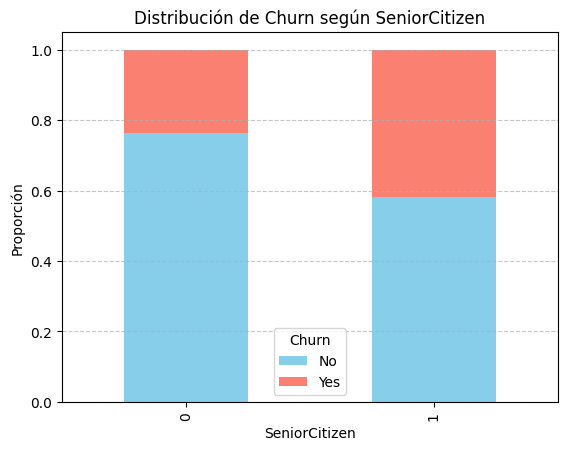

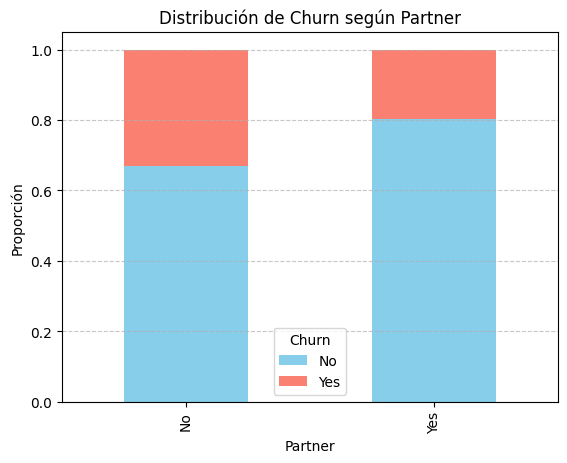

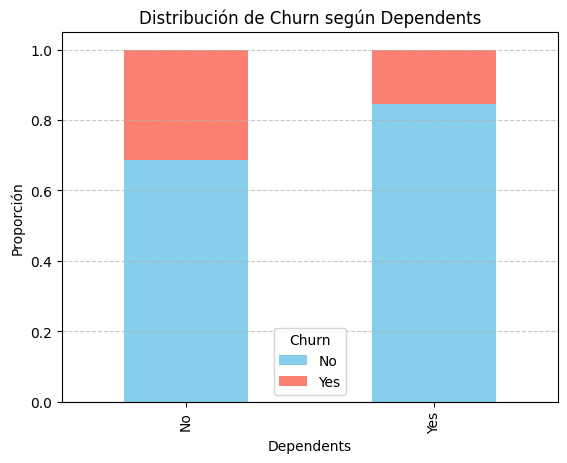

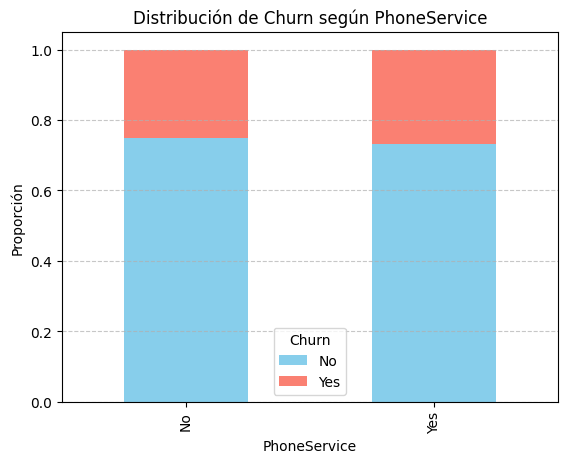

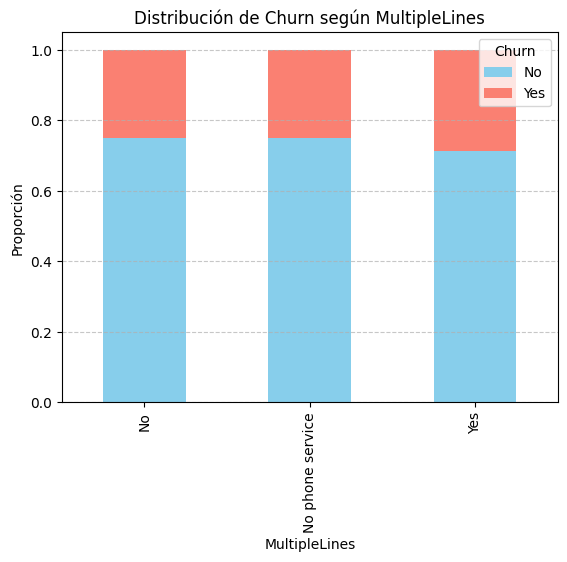

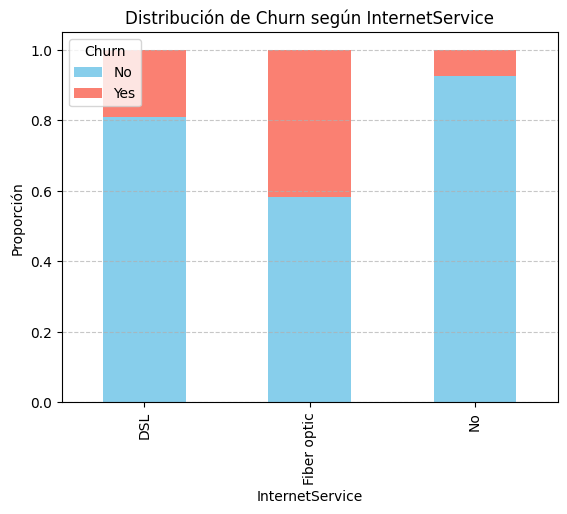

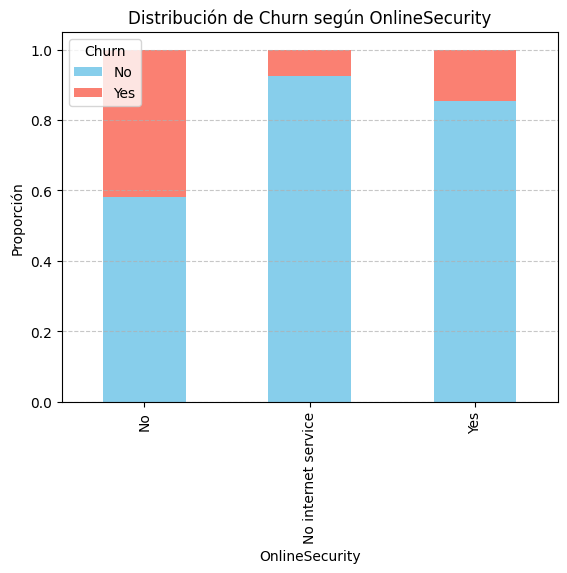

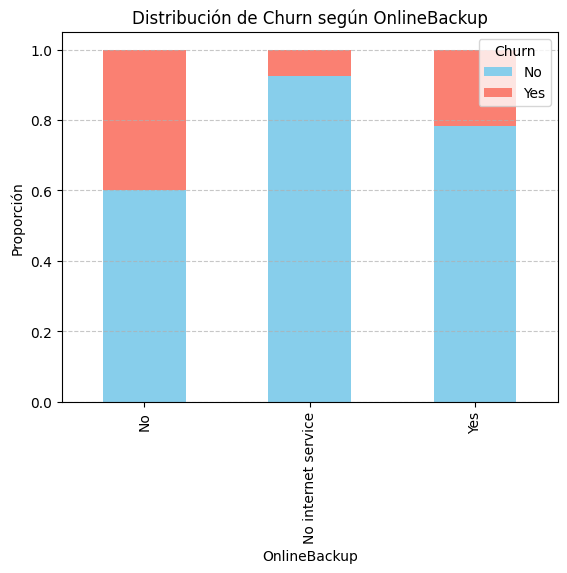

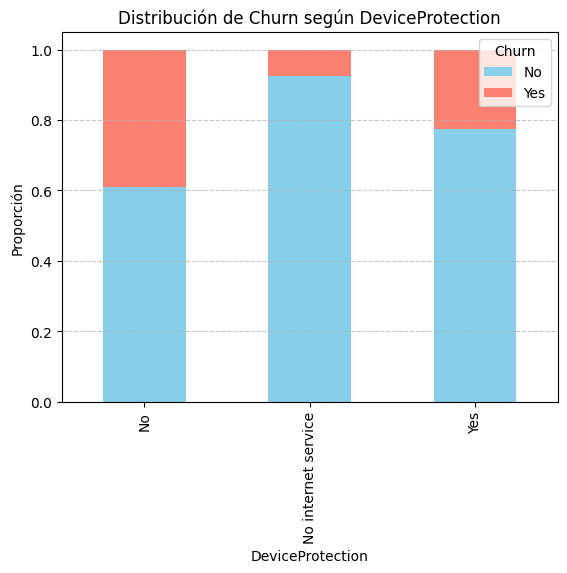

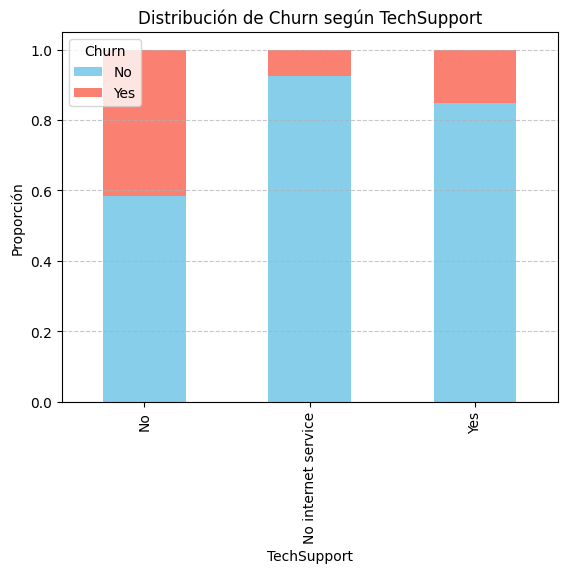

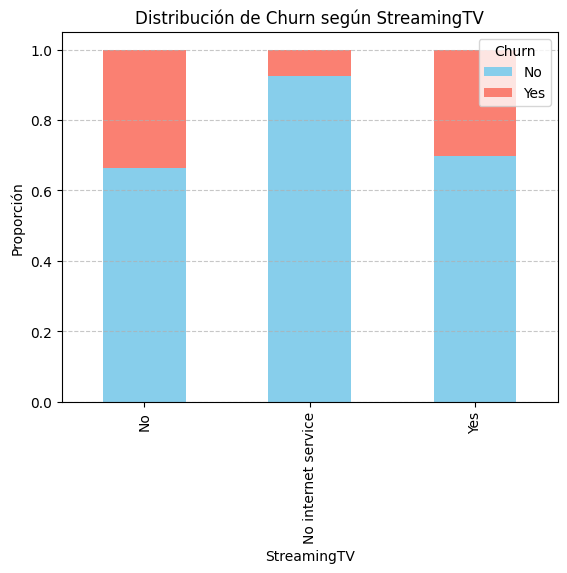

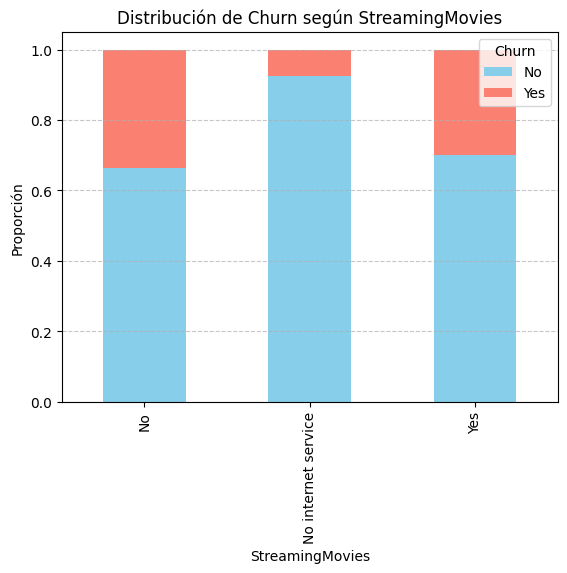

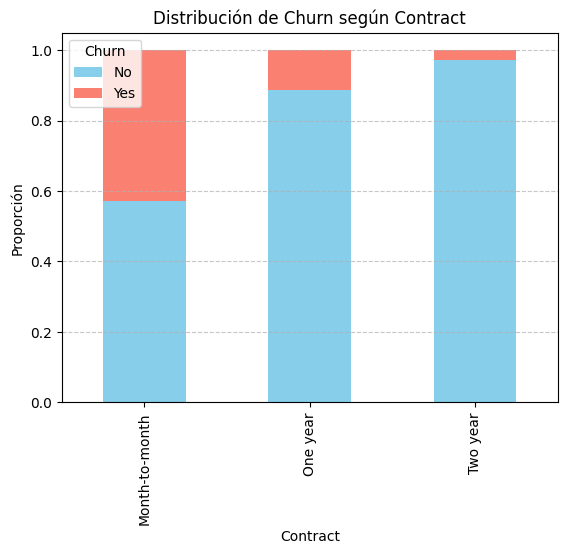

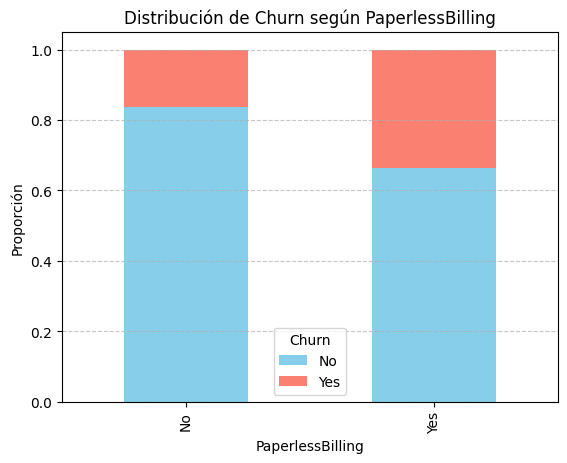

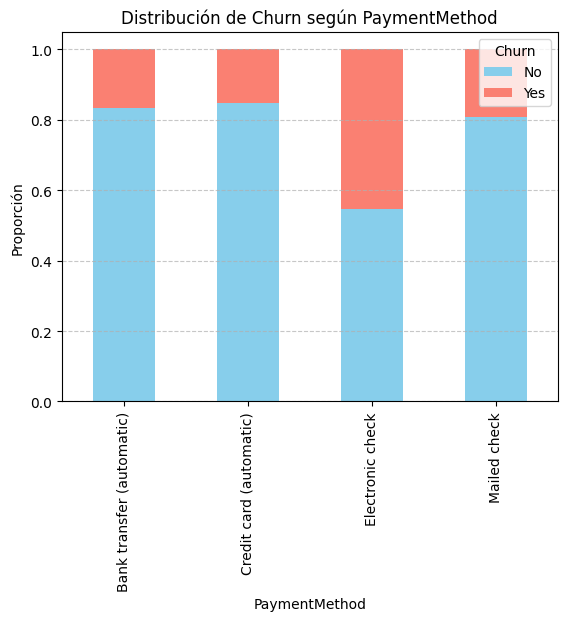

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

categoricas = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in categoricas:
    tabla = pd.crosstab(df_normalizado[col], df_normalizado['Churn'])
    tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)

    tabla_prop.plot(kind='bar', stacked=True, color=['skyblue','salmon'])
    plt.title(f"Distribución de Churn según {col}")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.legend(title="Churn")
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # ← activa rayas horizontales
    plt.show()

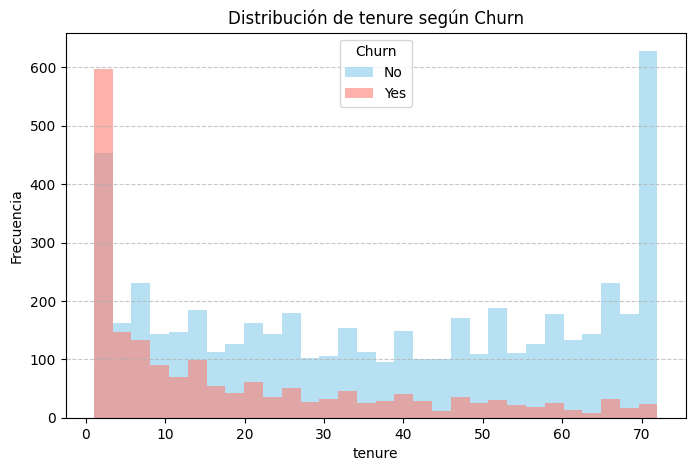

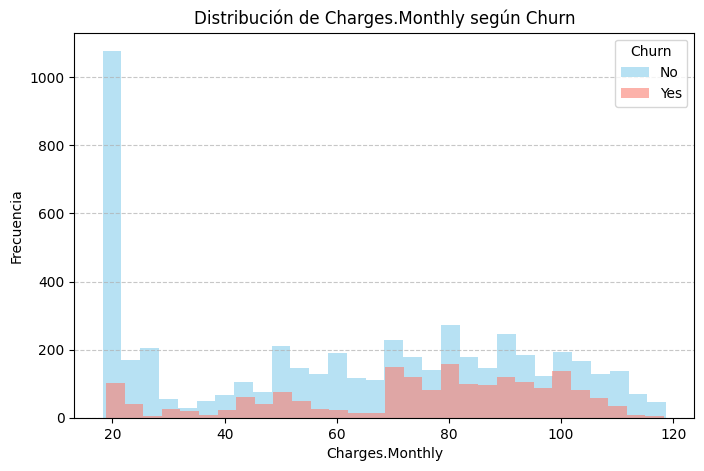

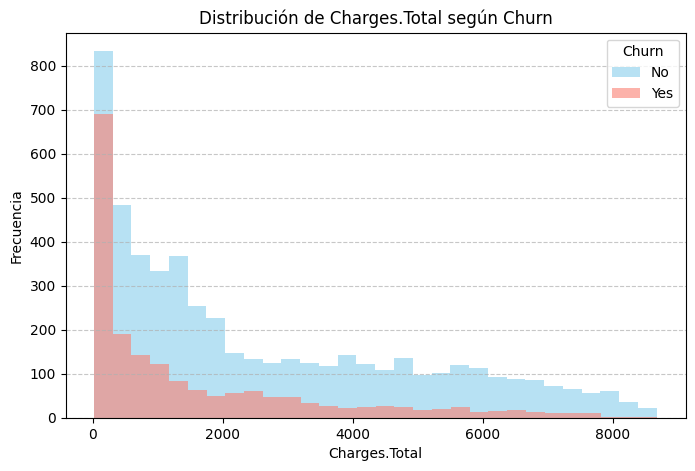

In [27]:
import matplotlib.pyplot as plt

numericas = ['tenure', 'Charges.Monthly', 'Charges.Total']

for col in numericas:
    plt.figure(figsize=(8,5))

    # Histograma separado por churn
    for churn_value, color in zip(['No','Yes'], ['skyblue','salmon']):
        df_normalizado[df_normalizado['Churn']==churn_value][col].plot(
            kind='hist', bins=30, alpha=0.6, color=color, label=churn_value
        )

    plt.title(f"Distribución de {col} según Churn")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.legend(title="Churn")
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # ← rayas de guía
    plt.show()

#📄Informe final

El objetivo de este análisis es comprender el fenómeno de evasión de clientes (churn) en la empresa Telecom X. La evasión representa la pérdida de clientes que deciden cancelar sus servicios, lo cual impacta directamente en los ingresos y la sostenibilidad del negocio.
Este estudio busca identificar patrones y factores asociados al churn, para orientar estrategias de retención y fidelización.
##Limpieza y Tratamiento de Datos
- Importación de datos: Se cargó el dataset con información de clientes y sus características.
-  Detección de duplicados: No se encontraron registros duplicados.
-  Valores faltantes:
  - Churn: se detectaron 224 valores vacíos, reemplazados por  y posteriormente eliminados.
  - Charges.Total: se detectaron 11 valores inválidos.
- Normalización de variables:
  - Conversión de Charges.Total  a numérico.
-  Resultado: Dataset limpio, coherente y listo para análisis exploratorio.
##Análisis Exploratorio de Datos (EDA)
Distribución de Churn
- Se observó que la mayoría de clientes permanecen en la empresa (No), mientras que una proporción menor se dio de baja (Yes).
- Gráficos de barras y torta mostraron la proporción global de churn.
Churn por Variables Categóricas
- Contract: Los clientes con contrato Month-to-month presentan mayor tasa de churn.
- PaymentMethod: Los clientes que pagan con Electronic check muestran mayor evasión.
- Servicios adicionales: Clientes sin OnlineSecurity o TechSupport tienen mayor probabilidad de cancelar.
- SeniorCitizen: Se observó una ligera diferencia en la evasión respecto a clientes mayores de 65 años.
Churn por Variables Numéricas
- tenure: Los clientes con menor tiempo de contrato son más propensos a cancelar.
- Charges.Monthly: Los clientes con cargos mensuales más altos tienden a mostrar mayor churn.
- Charges.Total: Los clientes que se fueron acumulan menos gasto total, reflejando cancelaciones tempranas.
##Conclusiones e Insights
1. 	La evasión está fuertemente asociada a contratos de corto plazo (Month-to-month).
2. 	El método de pago Electronic check es un indicador de mayor riesgo de churn.
3. 	La ausencia de servicios adicionales (seguridad, soporte técnico) incrementa la probabilidad de cancelación.
4. 	Los clientes nuevos (tenure bajo) son más vulnerables a la evasión.
5. 	Los clientes con cargos mensuales altos requieren atención especial para evitar insatisfacción.
##Recomendaciones Estratégicas
- Fidelización temprana: Implementar programas de bienvenida y beneficios para clientes en sus primeros meses.
- Incentivar contratos largos: Ofrecer descuentos o beneficios adicionales para contratos de 1 o 2 años.
- Mejorar experiencia de pago: Promover métodos de pago automáticos (tarjeta, transferencia) en lugar de Electronic check.
- Servicios de valor agregado: Incentivar la contratación de servicios adicionales como seguridad en línea y soporte técnico.
- Segmentación de clientes de alto riesgo: Identificar clientes con tenure bajo y cargos mensuales altos para campañas de retención personalizadas.